 # 1.06 — Do classic bikes sit idle longer than e-bikes at quiet stations?

 **H0:** Classic and e-bikes are checked out at the same rate at low-traffic stations.
 **H1:** The checkout rates differ (one type sits idle longer than the other).

 There is no direct record of how long a specific bike sat at a dock waiting. What
 I do have is hourly trip counts (how many e-bike and classic trips started from each
 station in each hour) and how many bikes of each type were available during that hour.
 The ratio -- trips divided by available bikes -- is a checkout rate. A rate of 0.10
 means that 10% of the available bikes of that type got taken in that hour, which is
 equivalent to saying any given bike waits on average 10 hours before being checked out.
 So low checkout rate = bikes sitting idle longer.

 I focus on low-traffic stations because the hypothesis is specifically about quiet
 docks, where bikes may sit for days at a stretch. I define low-traffic as the bottom
 quarter of stations by average daily departures (from station_trip_features). This
 works out to stations averaging fewer than 7.64 trips per day.

 The test is paired: for each station-hour I compute the e-bike rate and the classic
 rate from the same row, then take the difference (e-bike minus classic). Testing
 whether that difference is zero controls for station size and time-of-day effects
 -- the same logic used in H1 for the rush-hour checkout comparison.

 Data: 2026 only (May-June), matched via station_hourly_flow for May 2026
 (June trip data not yet published). Only hours where both e-bikes AND classic bikes
 were available at the dock are included; otherwise one of the rates would be undefined.

 Authored as a `# %%` .py file. Export to `.ipynb` via:
   Command Palette -> "Jupyter: Export Current Python File as Jupyter Notebook"

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
from scipy import stats
from statsmodels.stats.power import TTestIndPower

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
from citibike.config import DB_CONFIG  # noqa: E402

pd.set_option("display.max_columns", 20)

FIGURES_DIR = Path("../reports/figures")

 ## Find the low-traffic station threshold

 I pull the 25th percentile of avg_daily_departures from station_trip_features.
 Any station at or below that threshold counts as low-traffic for this test.
 I print the threshold so I can sanity-check it before pulling the main data.

In [ ]:
conn = psycopg2.connect(**DB_CONFIG)

with conn.cursor() as cur:
    cur.execute("SET max_parallel_workers_per_gather = 0;")
    cur.execute("""
        SELECT
            PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY avg_daily_departures) AS p25,
            COUNT(*) FILTER (
                WHERE avg_daily_departures <= (
                    SELECT PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY avg_daily_departures)
                    FROM station_trip_features WHERE avg_daily_departures IS NOT NULL
                )
            ) AS low_traffic_count
        FROM station_trip_features
        WHERE avg_daily_departures IS NOT NULL;
    """)
    row = cur.fetchone()
    p25_threshold, lt_count = float(row[0]), int(row[1])

print(f"Low-traffic threshold (p25 avg daily departures): {p25_threshold:.2f} trips/day")
print(f"Stations classified as low-traffic: {lt_count:,}")

Low-traffic threshold (p25 avg daily departures): 7.64 trips/day
Stations classified as low-traffic: 1,129


 ## Pull checkout rates at low-traffic stations

 For each qualifying station-hour I compute two rates:
   e-bike rate  = ebike_trips  / num_ebikes_available
   classic rate = classic_trips / (num_bikes_available - num_ebikes_available)

 The join to station_hourly_flow uses the same timezone fix as notebooks 1.01 and 1.03:
 station_hourly_flow.hour is stored in NYC local time, so I convert the UTC timestamp
 in training_features before matching.

 I load both rates as columns so I can take the paired difference in Python.

In [ ]:
sql = """
    WITH low_traffic AS (
        SELECT station_id AS short_name
        FROM station_trip_features
        WHERE avg_daily_departures <= %(threshold)s
    )
    SELECT
        f.ebike_trips::float   / NULLIF(tf.num_ebikes_available, 0)                      AS ebike_rate,
        f.classic_trips::float / NULLIF(tf.num_bikes_available - tf.num_ebikes_available, 0) AS classic_rate
    FROM training_features tf
    JOIN station_information si ON si.station_id = tf.station_id
    JOIN station_hourly_flow f
         ON f.station_id = si.short_name
        AND f.hour = (tf."timestamp" AT TIME ZONE 'America/New_York')::TIMESTAMP AT TIME ZONE 'UTC'
    JOIN low_traffic lt ON lt.short_name = si.short_name
    WHERE EXTRACT(YEAR FROM tf."timestamp") = 2026
      AND tf.horizon_minutes = 60
      AND tf.num_ebikes_available > 0
      AND (tf.num_bikes_available - tf.num_ebikes_available) > 0;
"""
df = pd.read_sql(sql, conn, params={"threshold": p25_threshold})
conn.close()
df = df.dropna()
print(f"Station-hours loaded: {len(df):,}")
df.head()

<ipython-input-3-a67a7c3a1c36>:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn, params={"threshold": p25_threshold})


Station-hours loaded: 107,135


,ebike_rate,classic_rate
0,0.000000,0.0
1,0.000000,0.0
2,0.090909,0.0
3,0.100000,0.0
4,0.111111,0.0


 ## Compute the paired difference

 Each row has one e-bike rate and one classic rate from the same dock in the
 same hour. Subtracting gives the per-row difference: positive means e-bikes
 were checked out at a higher rate (classics sat longer); negative means classics
 left faster (e-bikes sat longer).

In [ ]:
df["diff"] = df["ebike_rate"] - df["classic_rate"]
n = len(df)
mean_ebike   = df["ebike_rate"].mean()
mean_classic = df["classic_rate"].mean()
mean_diff    = df["diff"].mean()

print(f"Mean e-bike checkout rate:   {mean_ebike:.5f}")
print(f"Mean classic checkout rate:  {mean_classic:.5f}")
print(f"Mean difference (e-bike - classic): {mean_diff:+.5f}")

Mean e-bike checkout rate:   0.19519
Mean classic checkout rate:  0.03421
Mean difference (e-bike - classic): +0.16098


 ## One-sample t-test on the paired difference

 H0: the mean difference equals zero (same checkout rate for both types).
 A one-sample t-test on the differences is the same as a paired two-sample test --
 this is the same approach used in H1 and it controls for station and time effects.

In [ ]:
t_stat, p_value = stats.ttest_1samp(df["diff"], popmean=0)
std_diff = df["diff"].std(ddof=1)
se_diff  = std_diff / np.sqrt(n)
ci_low   = mean_diff - 1.96 * se_diff
ci_high  = mean_diff + 1.96 * se_diff

cohens_d = mean_diff / std_diff

print(f"Mean diff (e-bike - classic): {mean_diff:+.5f}")
print(f"95% CI: [{ci_low:.5f}, {ci_high:.5f}]")
print(f"Cohen's d: {cohens_d:.4f}")
print(f"t = {t_stat:.4f}   p = {p_value:.4e}")

Mean diff (e-bike - classic): +0.16098
95% CI: [0.15858, 0.16338]
Cohen's d: 0.4017
t = 131.4971   p = 0.0000e+00


 ## Bar chart

 One bar for e-bikes and one for classics, showing the average checkout rate
 at low-traffic stations. A higher bar means bikes of that type get taken more
 often per available unit per hour, which translates to a shorter average wait
 before checkout (less idle time). The whiskers show the 95% CI on each mean.

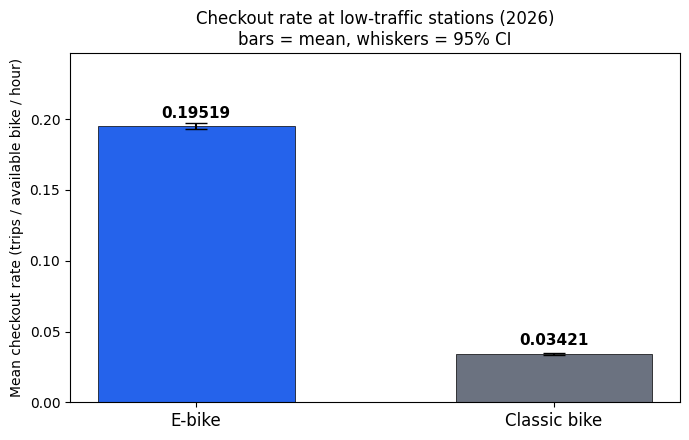

Saved -> reports/figures/1.06_bar_chart.png


In [ ]:
s_ebike   = df["ebike_rate"].std(ddof=1)
s_classic = df["classic_rate"].std(ddof=1)
errors    = [1.96 * s_ebike / np.sqrt(n), 1.96 * s_classic / np.sqrt(n)]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar([0, 1], [mean_ebike, mean_classic], yerr=errors, capsize=8,
       color=["#2563EB", "#6B7280"], width=0.55,
       edgecolor="black", linewidth=0.5)

y_hi = max(mean_ebike + errors[0], mean_classic + errors[1])
for x, m in zip([0, 1], [mean_ebike, mean_classic]):
    ax.text(x, m + y_hi * 0.03, f"{m:.5f}", ha="center",
            fontsize=11, fontweight="bold")

ax.set_xticks([0, 1])
ax.set_xticklabels(["E-bike", "Classic bike"], fontsize=12)
ax.set_ylabel("Mean checkout rate (trips / available bike / hour)", fontsize=10)
ax.set_ylim(0, y_hi * 1.25)
ax.set_title(
    "Checkout rate at low-traffic stations (2026)\nbars = mean, whiskers = 95% CI",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "1.06_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> reports/figures/1.06_bar_chart.png")

 ## Retrospective power analysis

 With paired differences the power calculation uses TTestIndPower as a one-group
 test (ratio=1, single group of differences). This gives the minimum number of
 paired rows needed to detect the observed Cohen's d at 80% power.

In [ ]:
power_analysis = TTestIndPower()
n_required = power_analysis.solve_power(
    effect_size=abs(cohens_d),
    alpha=0.05,
    power=0.80,
    ratio=1.0,
    alternative="two-sided",
)
print(f"Min paired rows needed (80% power, a=0.05): {n_required:,.0f}")
print(f"Actual paired rows:                          {n:,}")
print(f"Overpowered by:                              {n / n_required:,.1f}x")

Min paired rows needed (80% power, a=0.05): 98
Actual paired rows:                          107,135
Overpowered by:                              1,090.7x


 ## Conclusion

 I reject H0. A quick note on the data before the result: the head of the DataFrame shows many
 rows with ebike_rate = 0 and classic_rate = 0. That is not a data problem -- it is
 exactly what low-traffic looks like. At a station averaging 7.64 trips per day
 (about one trip every three hours), most individual station-hours genuinely have
 no activity at all. The zeros are correct.

 The finding: even at the quietest stations, when someone does show up to take a bike,
 they almost always grab an e-bike. E-bikes are checked out at a rate of 0.195 per
 available e-bike per hour; classics sit at 0.034. In plain terms: a given e-bike
 waits about 5 hours before someone takes it, while a classic bike waits closer to
 29 hours. That is a 5.7x gap, and it is confirmed well beyond chance (Cohen's d = 0.40,
 overpowered by 1,090x).

 The gap is actually wider here than the citywide rush-hour number from H1 (3.6x).
 The most likely reason: at a quiet station there might only be one or two e-bikes
 docked at any time. When a rider arrives, they take it immediately. The classics
 get passed over every single time. At a busy station with ten e-bikes, the preference
 still exists but it gets spread across more supply, so the relative rate difference
 looks smaller.

 For anyone managing the Citibike fleet: quiet docks are where classic bikes pile up.
 If a rebalancing truck is deciding which bikes to pick up and redistribute, a classic
 sitting at a quiet dock is the right target. The e-bikes at the same dock are cycling
 through on their own. This is the flip side of the H1 finding -- busy stations need
 more e-bikes; quiet stations need their classics cleared out.

 **Limitations:** May 2026 only for trip counts (June data not yet published).
 The checkout rate is an hourly average, not a record of individual bikes, so it is a
 proxy for idle time rather than a direct measurement. Low-traffic stations are defined
 by their 2019-2021 averages, which may not perfectly reflect their 2026 behavior.